# 🏦 Análise Consolidada do Mercado de Crédito Brasileiro
Este notebook reúne as visões macroeconômicas nacionais, regionais e estaduais sobre o mercado de crédito.
O objetivo é identificar oportunidades de crédito inclusivo apoiando decisões estratégicas.

**Fontes de Dados**: API do Banco Central do Brasil (SGS/BCData)
**Técnicas**: ETL de múltiplas séries, Visualização de Dados Geográficos, Score de Oportunidades e Simulação de Monte Carlo.



In [7]:
# ============================================================
# 0. SETUP E INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
# Caso não tenha a biblioteca do Banco Central instalada, descomente a linha abaixo:
!pip install python-bcb pandas numpy matplotlib seaborn plotly requests --quiet

import pandas as pd
import numpy as np
import requests
import warnings
import time
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

# Extratores do BCB
from bcb import sgs
from bcb.sgs.regional_economy import get_non_performing_loans

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px

# Configurações globais
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.family'] = 'sans-serif'

# Constantes globais
START_DATE = '2019-01-01'
TODAY = datetime.today().strftime('%Y-%m-%d')

REGIOES = {
    'Norte':       ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste':    ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste':['DF', 'GO', 'MS', 'MT'],
    'Sudeste':     ['ES', 'MG', 'RJ', 'SP'],
    'Sul':         ['PR', 'RS', 'SC'],
}

CORES_REGIAO = {
    'Norte':        '#1a1a6e',
    'Nordeste':     '#7b2d8b',
    'Centro-Oeste': '#e05c5c',
    'Sudeste':      '#e8a87c',
    'Sul':          '#4b0082',
}

UF_PARA_REGIAO = {uf: regiao for regiao, estados in REGIOES.items() for uf in estados}
print("✅ Bibliotecas carregadas e parâmetros configurados!")



✅ Bibliotecas carregadas e parâmetros configurados!


---
## 1️⃣ Extração de Dados Macroeconômicos (ETL 1)
Busca concorrente de indicadores globais utilizando diretamente a API REST do SGS.



In [8]:
# ============================================================
# 1. ETL 1 — INDICADORES MACRO (BRASIL)
# ============================================================
class BacenSGSClient:
    BASE_URL = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"

    @staticmethod
    def extrair_serie(codigo, nome, data_inicial):
        url = BacenSGSClient.BASE_URL.format(codigo=codigo)
        parametros = {'formato': 'json', 'dataInicial': pd.Timestamp(data_inicial).strftime('%d/%m/%Y')}
        try:
            resposta = requests.get(url, params=parametros, timeout=15)
            resposta.raise_for_status()
            df = pd.DataFrame(resposta.json())
            df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')
            df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
            df.set_index('data', inplace=True)
            df.rename(columns={'valor': nome}, inplace=True)
            return df
        except Exception as e:
            print(f"[Erro] Falha ao extrair a série {codigo} ({nome}): {e}")
            return pd.DataFrame()

SERIES_MACRO = {
    'Credito_Total_SFN':        20539,
    'Credito_PF':               20540,
    'Credito_PJ':               20541,
    'Inadimplencia_Total_BR':   21082,
    'Endividamento_Familias':   29038,
    'Taxa_Juros_Media':         20721,
    'IPCA_Mensal':              433,
    'Selic_Meta':               432
}

print("🔄 Buscando indicadores macroeconômicos (Multithreading)...")
df_macro = pd.DataFrame()
lista_dfs = []

with ThreadPoolExecutor(max_workers=5) as executor:
    futuros = {executor.submit(BacenSGSClient.extrair_serie, cod, nome, START_DATE): nome for nome, cod in SERIES_MACRO.items()}
    for futuro in as_completed(futuros):
        nome = futuros[futuro]
        res = futuro.result()
        if not res.empty:
            lista_dfs.append(res)
            print(f"  ✅ {nome}: {len(res)} observações")

if lista_dfs:
    df_macro = pd.concat(lista_dfs, axis=1).sort_index().ffill().dropna(how='all')
    print("\n📊 Preview Macro:")
    display(df_macro.tail(3))



🔄 Buscando indicadores macroeconômicos (Multithreading)...
  ✅ Credito_Total_SFN: 85 observações
  ✅ Credito_PF: 85 observações
  ✅ Credito_PJ: 85 observações
  ✅ Endividamento_Familias: 84 observações
  ✅ Inadimplencia_Total_BR: 85 observações
  ✅ Taxa_Juros_Media: 85 observações
  ✅ IPCA_Mensal: 86 observações
[Erro] Falha ao extrair a série 432 (Selic_Meta): HTTPSConnectionPool(host='api.bcb.gov.br', port=443): Read timed out. (read timeout=15)

📊 Preview Macro:


,Credito_Total_SFN,Credito_PF,Credito_PJ,Endividamento_Familias,Inadimplencia_Total_BR,Taxa_Juros_Media,IPCA_Mensal
data,,,,,,,
2025-12-01,7130222.00,2701245.00,4428977.00,31.22,4.03,17.79,0.33
2026-01-01,7115576.00,2654860.00,4460716.00,31.22,4.25,17.01,0.33
2026-02-01,7115576.00,2654860.00,4460716.00,31.22,4.25,17.01,0.70


---
## 2️⃣ Extração de Inadimplência por Estado (ETL 2)
Utilizamos a biblioteca oficial `python-bcb` para obter os dados estaduais de inadimplência (Total, PF e PJ).



In [9]:
# ============================================================
# 2. ETL 2 — INADIMPLÊNCIA POR ESTADO (python-bcb)
# ============================================================
print("🔄 Buscando dados de inadimplência por estado...")
TODOS_OS_ESTADOS = [uf for estados in REGIOES.values() for uf in estados]

print("📥 Inadimplência Total...")
inadimplencia_total = get_non_performing_loans(TODOS_OS_ESTADOS, mode='all', start=START_DATE)
print("📥 Inadimplência Pessoa Física...")
inadimplencia_pf = get_non_performing_loans(TODOS_OS_ESTADOS, mode='pf', start=START_DATE)
print("📥 Inadimplência Pessoa Jurídica...")
inadimplencia_pj = get_non_performing_loans(TODOS_OS_ESTADOS, mode='pj', start=START_DATE)

# Pivoting para formato Long
def wide_to_long(df, nome_variavel):
    return (df.reset_index().melt(id_vars='Date', var_name='UF', value_name=nome_variavel)
            .assign(Regiao=lambda d: d['UF'].map(UF_PARA_REGIAO))
            .rename(columns={'Date': 'Data'}))

inadimplencia_long = (
    wide_to_long(inadimplencia_total, 'Inadimplencia_Total')
    .merge(wide_to_long(inadimplencia_pf, 'Inadimplencia_PF')[['Data','UF','Inadimplencia_PF']], on=['Data','UF'], how='left')
    .merge(wide_to_long(inadimplencia_pj, 'Inadimplencia_PJ')[['Data','UF','Inadimplencia_PJ']], on=['Data','UF'], how='left')
)

inadimplencia_recente = (
    inadimplencia_long.dropna(subset=['Inadimplencia_Total']).sort_values('Data')
    .groupby('UF').last().reset_index()[['UF', 'Regiao', 'Inadimplencia_Total', 'Inadimplencia_PF', 'Inadimplencia_PJ']]
    .sort_values('Inadimplencia_Total', ascending=False)
)

print("\n📊 Inadimplência mais recente por UF:")
display(inadimplencia_recente.head())



🔄 Buscando dados de inadimplência por estado...
📥 Inadimplência Total...
📥 Inadimplência Pessoa Física...
📥 Inadimplência Pessoa Jurídica...

📊 Inadimplência mais recente por UF:


,UF,Regiao,Inadimplencia_Total,Inadimplencia_PF,Inadimplencia_PJ
9,MA,Nordeste,7.89,8.39,6.11
26,TO,Norte,7.84,9.03,4.56
11,MS,Centro-Oeste,6.44,7.17,4.56
8,GO,Centro-Oeste,6.37,7.08,4.24
20,RO,Norte,6.06,6.05,6.13


---
## 3️⃣ Análise — Brasil Geral 🇧🇷
Evolução do Saldo de Crédito, Inadimplência Nacional e panorama macroeconômico (Selic vs IPCA vs Inadimplência).



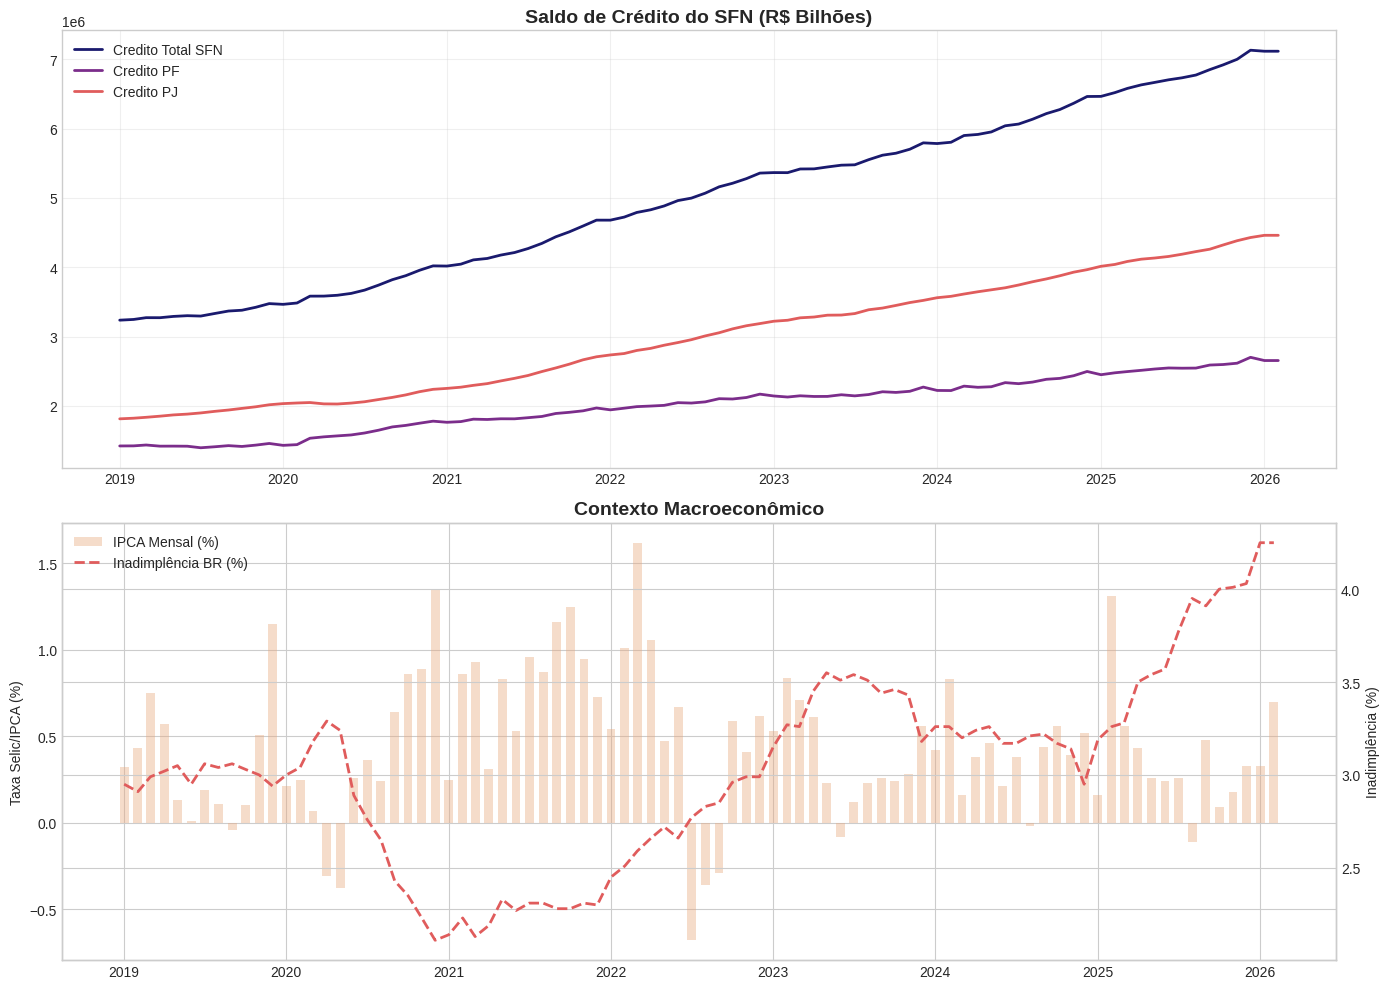

In [10]:
# ============================================================
# 3. ANÁLISE MACROECONÔMICA
# ============================================================
cols_credito = ['Credito_Total_SFN', 'Credito_PF', 'Credito_PJ']
disp_cred = [c for c in cols_credito if c in df_macro.columns]

if disp_cred:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    cores = ['#1a1a6e', '#7b2d8b', '#e05c5c']

    # Saldo
    for col, cor in zip(disp_cred, cores):
        axes[0].plot(df_macro.index, df_macro[col], label=col.replace('_', ' '), color=cor, lw=2)
    axes[0].set_title('Saldo de Crédito do SFN (R$ Bilhões)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Inadimplência / Selic / IPCA
    if 'Inadimplencia_Total_BR' in df_macro.columns:
        ax2 = axes[1].twinx()
        if 'IPCA_Mensal' in df_macro.columns:
            axes[1].bar(df_macro.index, df_macro['IPCA_Mensal'], alpha=0.4, color='#e8a87c', label='IPCA Mensal (%)', width=20)
        if 'Selic_Meta' in df_macro.columns:
            axes[1].plot(df_macro.index, df_macro['Selic_Meta'], color='#1a1a6e', lw=2, label='Selic Meta (%)')

        ax2.plot(df_macro.index, df_macro['Inadimplencia_Total_BR'], color='#e05c5c', lw=2, linestyle='--', label='Inadimplência BR (%)')

        axes[1].set_title('Contexto Macroeconômico', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Taxa Selic/IPCA (%)')
        ax2.set_ylabel('Inadimplência (%)')

        lines1, labels1 = axes[1].get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()



---
## 4️⃣ Análise por Macrorregião 🗺️
Distribuição da inadimplência média nas 5 macrorregiões do país.



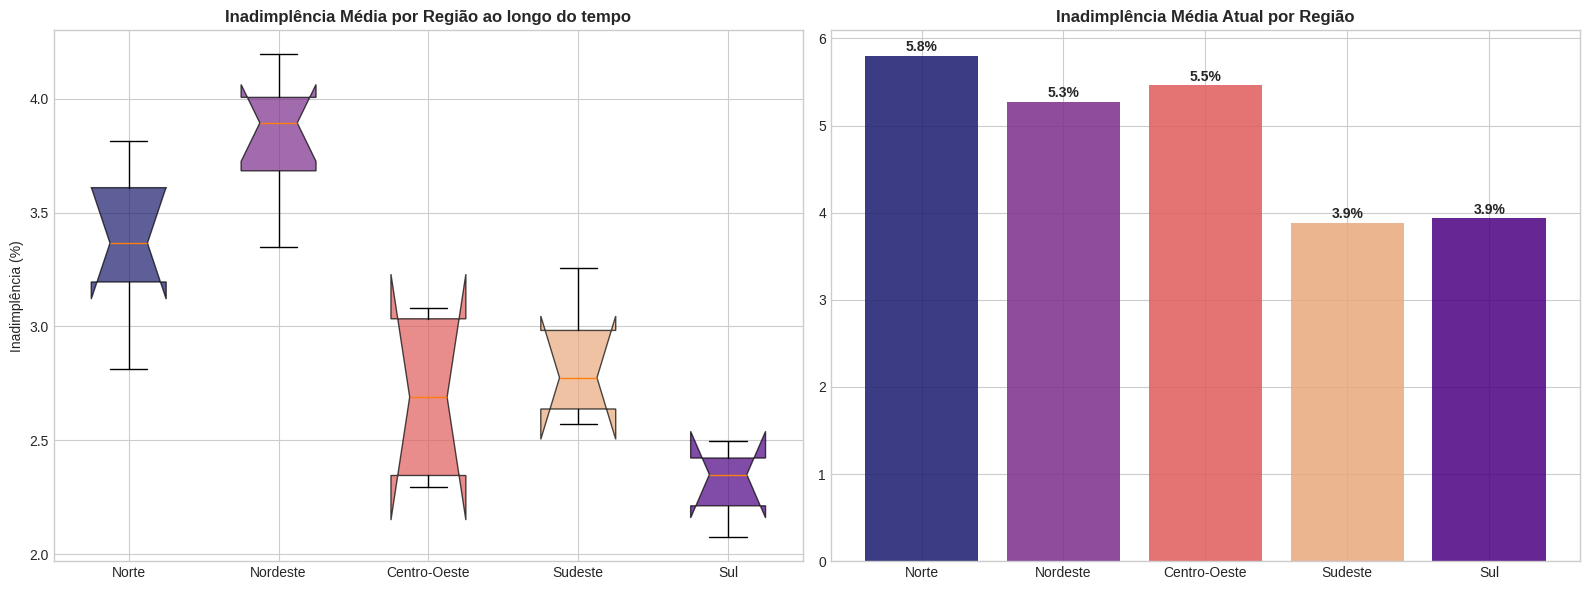

In [11]:
# ============================================================
# 4. ANÁLISE MACRORREGIONAL
# ============================================================
inadim_media_uf = inadimplencia_long.dropna(subset=['Inadimplencia_Total']).groupby(['UF', 'Regiao'])['Inadimplencia_Total'].agg(['mean', 'last']).reset_index()
ordem_regioes = list(REGIOES.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
dados_box = [inadim_media_uf[inadim_media_uf['Regiao'] == r]['mean'].values for r in ordem_regioes]
bp = axes[0].boxplot(dados_box, labels=ordem_regioes, patch_artist=True, notch=True)
for patch, regiao in zip(bp['boxes'], ordem_regioes):
    patch.set_facecolor(CORES_REGIAO[regiao])
    patch.set_alpha(0.7)
axes[0].set_title('Inadimplência Média por Região ao longo do tempo', fontweight='bold')
axes[0].set_ylabel('Inadimplência (%)')

# Barras
media_regiao = inadim_media_uf.groupby('Regiao')['last'].mean().reindex(ordem_regioes)
axes[1].bar(media_regiao.index, media_regiao.values, color=[CORES_REGIAO[r] for r in ordem_regioes], alpha=0.85)
for i, v in enumerate(media_regiao.values):
    axes[1].text(i, v + 0.05, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Inadimplência Média Atual por Região', fontweight='bold')

plt.tight_layout()
plt.show()



---
## 5️⃣ Análise Estadual (UFs) 📍
Heatmap dos últimos 24 meses e Scatterplot comparativo entre dívidas de PF e PJ.



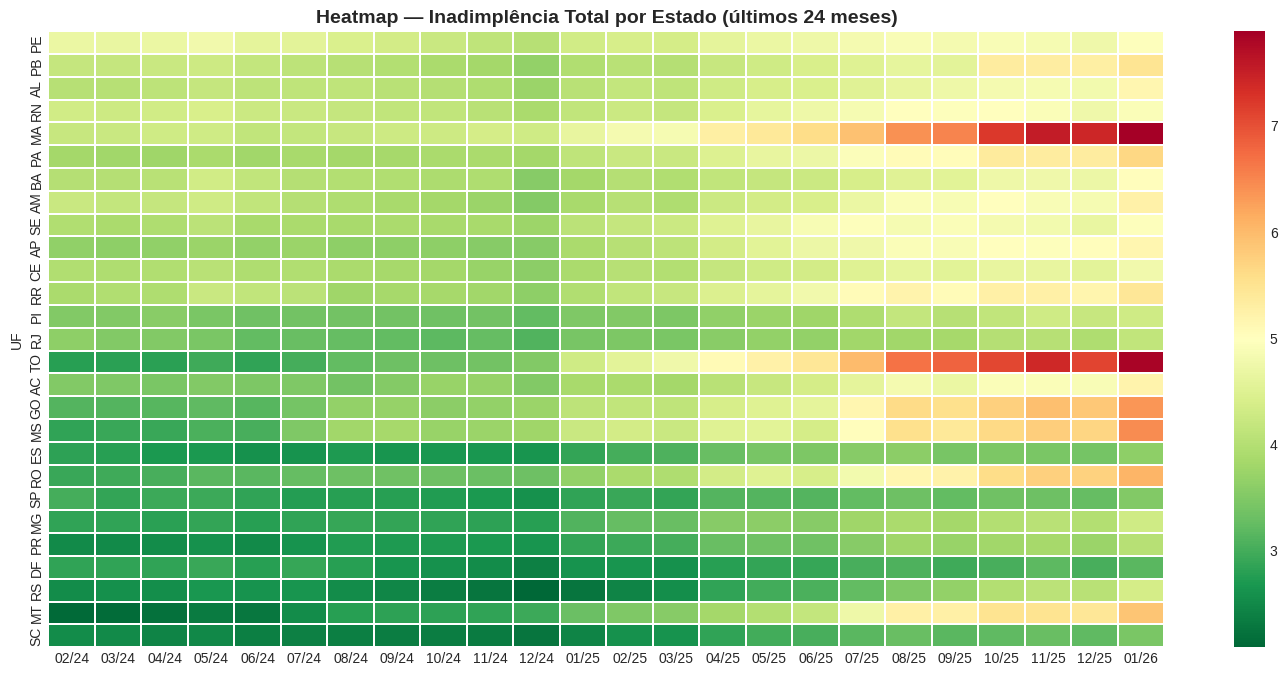

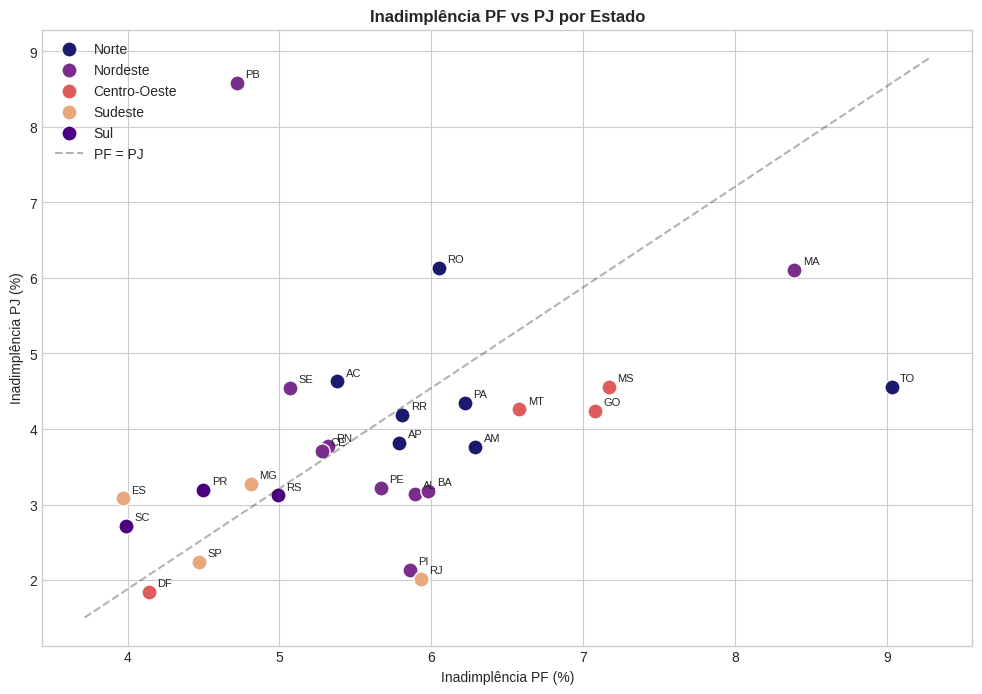

In [12]:
# ============================================================
# 5. ANÁLISE ESTADUAL (HEATMAP E SCATTER)
# ============================================================
pivot_inadim = inadimplencia_long[['Data','UF','Inadimplencia_Total']].dropna().pivot_table(index='UF', columns='Data', values='Inadimplencia_Total')
pivot_inadim = pivot_inadim.loc[pivot_inadim.mean(axis=1).sort_values(ascending=False).index]
pivot_inadim_24 = pivot_inadim.iloc[:, -24:]
pivot_inadim_24.columns = [d.strftime('%m/%y') for d in pivot_inadim_24.columns]

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_inadim_24, cmap='RdYlGn_r', annot=False, linewidths=0.3)
plt.title('Heatmap — Inadimplência Total por Estado (últimos 24 meses)', fontsize=14, fontweight='bold')
plt.show()

# Scatter PF vs PJ
fig, ax = plt.subplots(figsize=(12, 8))
for regiao, cor in CORES_REGIAO.items():
    d = inadimplencia_recente[inadimplencia_recente['Regiao'] == regiao]
    ax.scatter(d['Inadimplencia_PF'], d['Inadimplencia_PJ'], color=cor, s=120, label=regiao, edgecolors='white')
    for _, row in d.iterrows():
        ax.annotate(row['UF'], (row['Inadimplencia_PF'], row['Inadimplencia_PJ']), textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.plot([min(ax.get_xlim()), max(ax.get_xlim())], [min(ax.get_ylim()), max(ax.get_ylim())], 'k--', alpha=0.3, label='PF = PJ')
ax.set_xlabel('Inadimplência PF (%)')
ax.set_ylabel('Inadimplência PJ (%)')
ax.set_title('Inadimplência PF vs PJ por Estado', fontweight='bold')
ax.legend()
plt.show()



---
## 6️⃣ Foco Específico: Minas Gerais 🔺



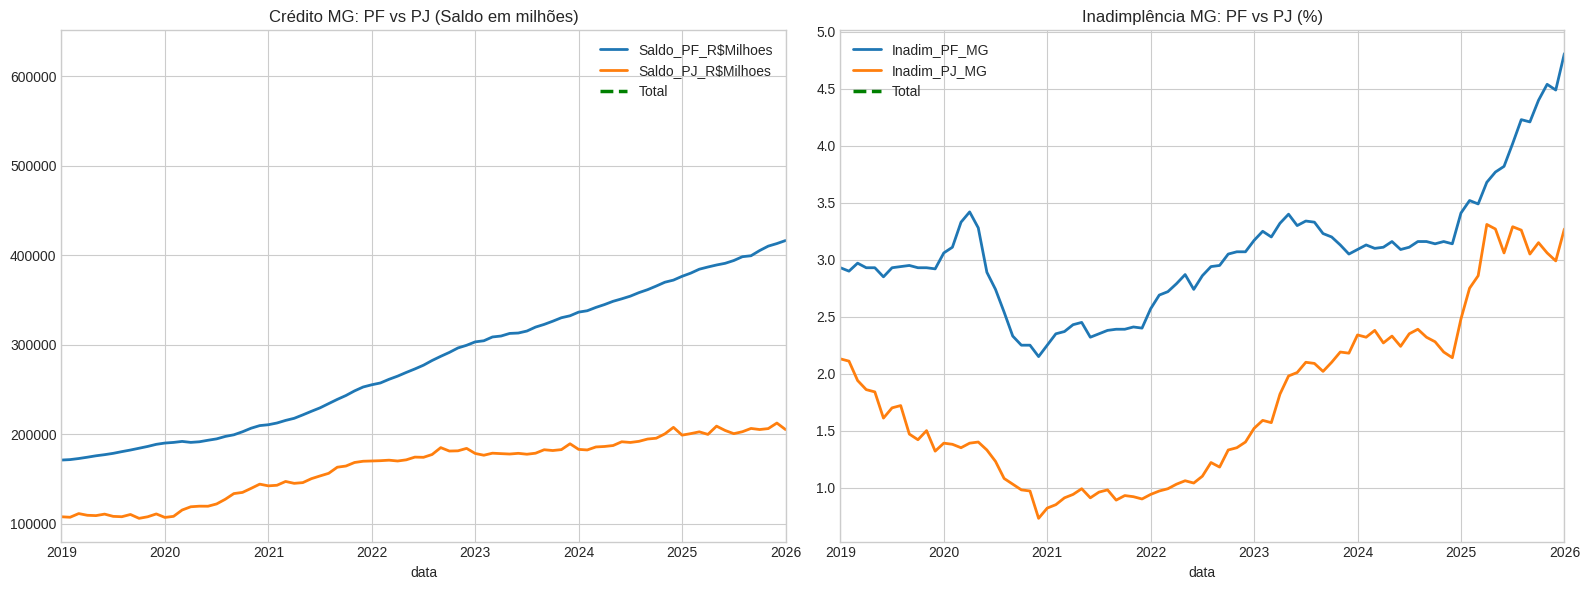

In [13]:
# ============================================================
# 6. ESTUDO DE CASO: MINAS GERAIS
# ============================================================
SERIES_MG = {
    14014: 'Saldo_PF_R$Milhoes',
    14041: 'Saldo_PJ_R$Milhoes',
    14068: 'Saldo_Total_R$Milhoes',
    15873: 'Inadim_PF_MG',
    15905: 'Inadim_PJ_MG',
    15937: 'Inadim_Total_MG'
}

df_mg = fetch_multiplas_series(SERIES_MG, start=START_DATE) if 'fetch_multiplas_series' in globals() else pd.DataFrame() # Fallback function
if df_mg.empty:
    lista_mg = []
    for cod, nome in SERIES_MG.items():
        r = BacenSGSClient.extrair_serie(cod, nome, START_DATE)
        if not r.empty: lista_mg.append(r)
    if lista_mg:
        df_mg = pd.concat(lista_mg, axis=1).ffill().dropna()

if not df_mg.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    df_mg[['Saldo_PF_R$Milhoes', 'Saldo_PJ_R$Milhoes']].plot(ax=axes[0], lw=2)
    axes[0].plot(df_mg.index, df_mg['Saldo_Total_R$Milhoes'], 'g--', lw=2.5, label='Total')
    axes[0].set_title('Crédito MG: PF vs PJ (Saldo em milhões)')
    axes[0].legend()

    df_mg[['Inadim_PF_MG', 'Inadim_PJ_MG']].plot(ax=axes[1], lw=2)
    axes[1].plot(df_mg.index, df_mg['Inadim_Total_MG'], 'g--', lw=2.5, label='Total')
    axes[1].set_title('Inadimplência MG: PF vs PJ (%)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()



---
## 7️⃣ Score de Oportunidade de Crédito Inclusivo 🏆
Combinamos indicadores de Inadimplência atual e a tendência de melhora (últimos 12 meses) para calcular a viabilidade de expansão por estado.



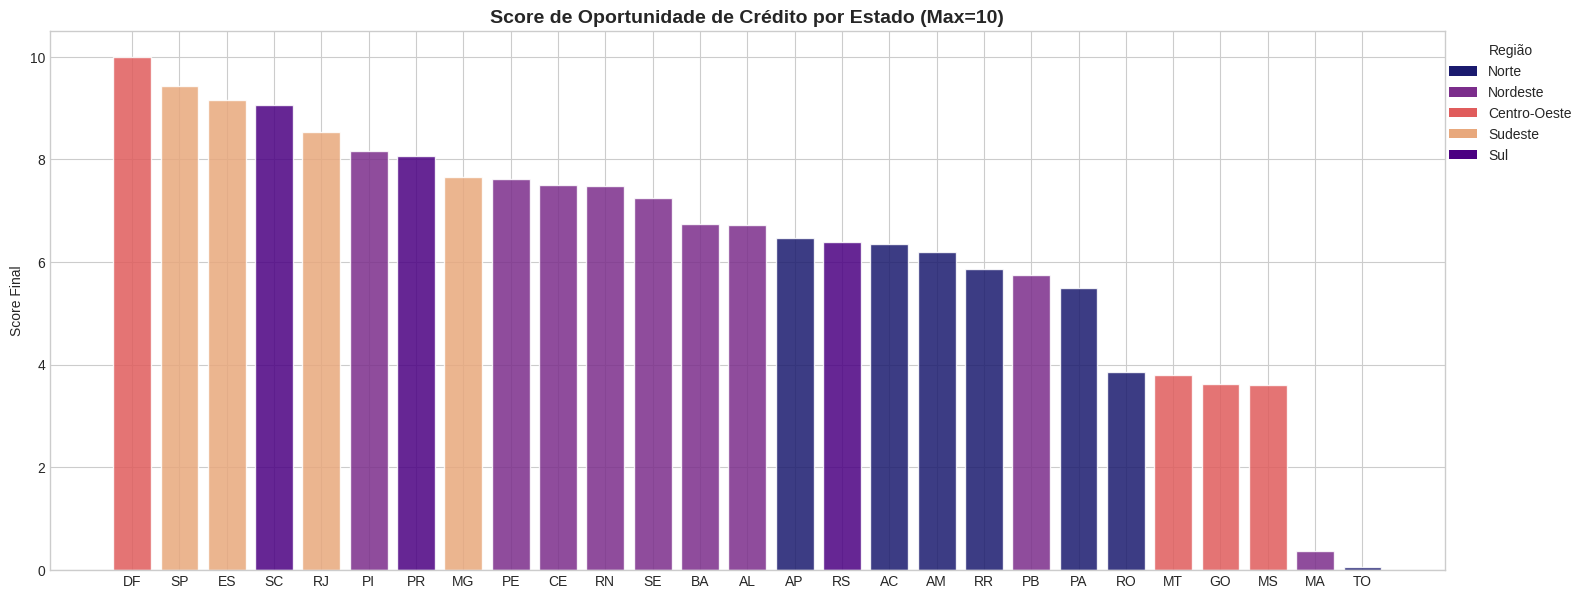

In [14]:
# ============================================================
# 7. MAPA DE OPORTUNIDADES
# ============================================================
def minmax_normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

score_df = inadimplencia_recente.copy().set_index('UF')

# Variação 12m
ult_data = inadimplencia_total.index[-1]
data_12m = inadimplencia_total.index[-13] if len(inadimplencia_total) > 12 else inadimplencia_total.index[0]
var_12m = (inadimplencia_total.loc[ult_data] - inadimplencia_total.loc[data_12m]).rename('var_12m')
score_df = score_df.join(var_12m, how='left')

# Inversão: menor inadimp e queda na inadimp = maior score
score_df['s_inadim']    = 1 - minmax_normalizar(score_df['Inadimplencia_Total'].fillna(score_df['Inadimplencia_Total'].median()))
score_df['s_tendencia'] = 1 - minmax_normalizar(score_df['var_12m'].fillna(0))

PESOS = {'s_inadim': 0.60, 's_tendencia': 0.40}
score_df['Score_Final'] = (score_df['s_inadim']*PESOS['s_inadim'] + score_df['s_tendencia']*PESOS['s_tendencia']) * 10
score_df = score_df.sort_values('Score_Final', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(18, 7))
cores_bar = [CORES_REGIAO[r] for r in score_df['Regiao']]
ax.bar(score_df['UF'], score_df['Score_Final'], color=cores_bar, alpha=0.85, edgecolor='white')

ax.set_title('Score de Oportunidade de Crédito por Estado (Max=10)', fontweight='bold', fontsize=14)
ax.set_ylabel('Score Final')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=r) for r, c in CORES_REGIAO.items()], title='Região', bbox_to_anchor=(1.1, 1))
plt.show()



---
## 8️⃣ Simulação Estocástica de Risco — Monte Carlo 🎲
Calculamos as perdas máximas esperadas (Value at Risk - VaR 95%) para um portfólio de crédito simulado nos estados listados.



🔄 Executando Simulação Monte Carlo com 15000 cenários baseados no Score...


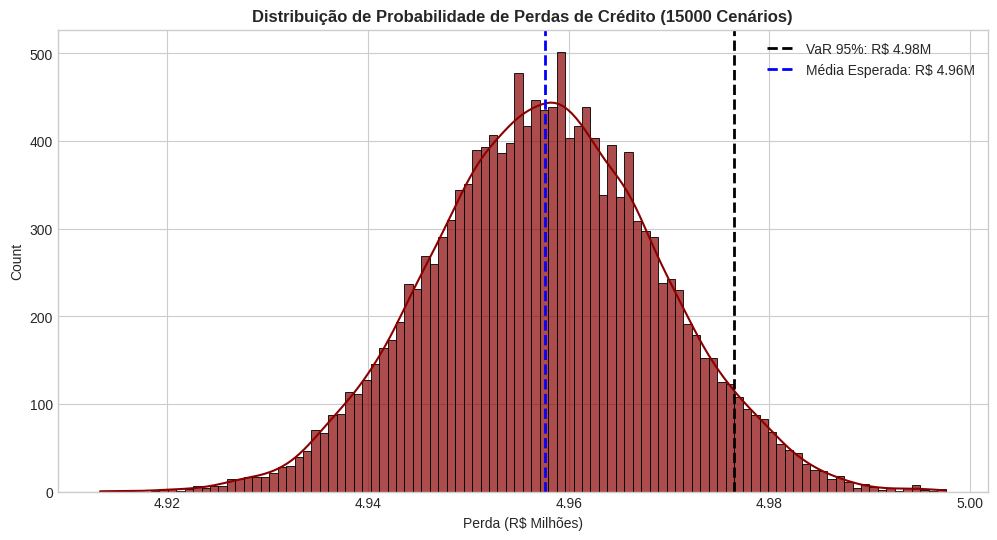

In [15]:
# ============================================================
# 8. SIMULAÇÃO MONTE CARLO
# ============================================================
montante_investimento_mm = 150.0  # R$ 150 Milhões na carteira
iters = 15000

print(f"🔄 Executando Simulação Monte Carlo com {iters} cenários baseados no Score...")
medias_historicas_inad = score_df['Inadimplencia_Total'].values / 100.0
volatilidade_inad = medias_historicas_inad * 0.20
exposicao_estado = montante_investimento_mm / len(score_df)

choques = np.random.normal(0, 1, size=(len(score_df), iters))
# Choque log-normal
inad_sim = medias_historicas_inad[:, None] * np.exp(-0.5 * volatilidade_inad[:, None]**2 + volatilidade_inad[:, None] * choques)

lgd = 0.65 # Loss given default conservador
matriz_perdas = exposicao_estado * inad_sim * lgd
perdas_totais = np.sum(matriz_perdas, axis=0)

var_95 = np.percentile(perdas_totais, 95)
media_perda = np.mean(perdas_totais)

plt.figure(figsize=(12, 6))
sns.histplot(perdas_totais, bins=100, color='#8B0000', alpha=0.7, kde=True)
plt.axvline(var_95, color='black', ls='--', lw=2, label=f'VaR 95%: R$ {var_95:.2f}M')
plt.axvline(media_perda, color='blue', ls='--', lw=2, label=f'Média Esperada: R$ {media_perda:.2f}M')
plt.title(f'Distribuição de Probabilidade de Perdas de Crédito ({iters} Cenários)', fontweight='bold')
plt.xlabel('Perda (R$ Milhões)')
plt.legend()
plt.show()

